In [12]:
from torchvision import transforms
import torch
from torchvision.models import resnet50
from torchvision.models import ResNet50_Weights

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create model structure
model = resnet50(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, 5)

# Load trained weights
model.load_state_dict(torch.load("sugarcane_resnet50.pth", map_location=device))

model.to(device)
model.eval()

print("Model loaded successfully.")
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])



Model loaded successfully.


In [13]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Load test dataset
test_data = datasets.ImageFolder("output/test", transform=val_transform)
test_loader = DataLoader(test_data, batch_size=32)

all_confidences = []
all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)

        confidence, predicted = torch.max(probs, 1)

        all_confidences.extend(confidence.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_confidences = np.array(all_confidences)
all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

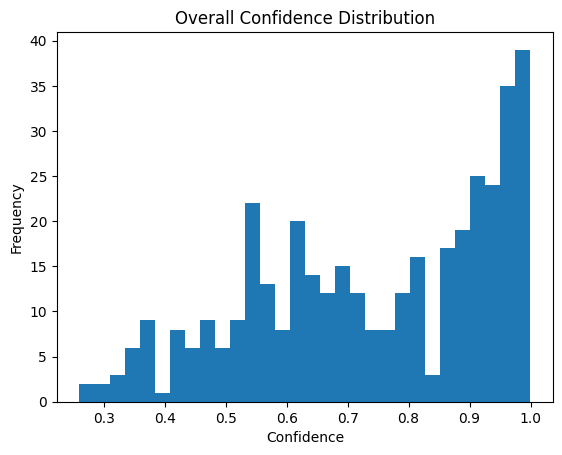

In [14]:
plt.hist(all_confidences, bins=30)
plt.title("Overall Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()